In [1]:
# importing libraries
import time
import numpy as np
import matplotlib.pyplot as plt

### Homework 2

Problem 4, part c

In [17]:
# given variables
a = 0.9
lam_f = 1000
lam_s = 10
N = 100_000

is_fast = np.random.uniform(0, 1, N) < a # drawing Bernoulli

u = np.random.uniform(0, 1, N) # inverse transform distribution

# computing dwell times
dwell_times = np.where(is_fast, -np.log(1 - u) / lam_f, -np.log(1 - u) / lam_s)

target = 0.05
theoretical_mean = (a / lam_f) + ((1 - a) / lam_s) # expected value
theoretical_probability = a * np.exp(-lam_f * target) + (1 - a) * np.exp(-lam_s * target)

empirical_mean = np.mean(dwell_times)
empirical_probability = np.mean(dwell_times > target)

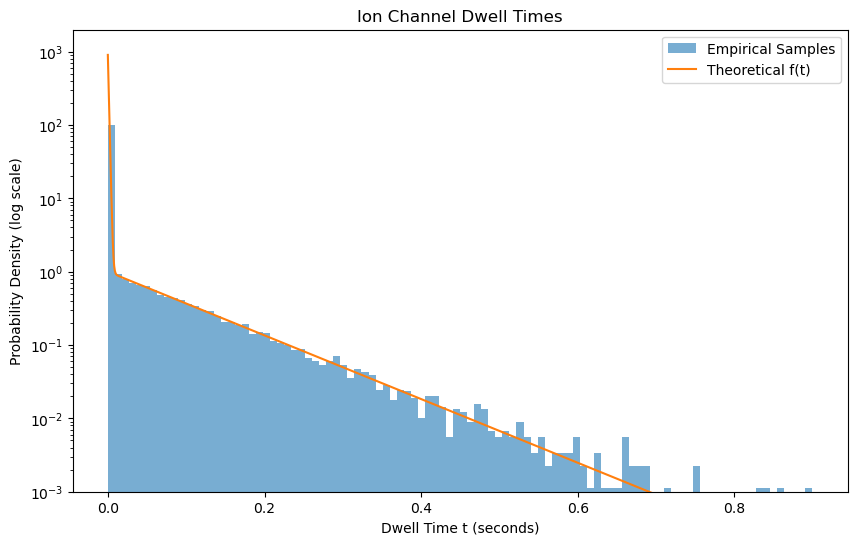

In [18]:
plt.figure(figsize = (10, 6))

counts, bins, _ = plt.hist(dwell_times, bins = 100, density = True, alpha = 0.6, label = 'Empirical Samples')
t_vals = np.linspace(0, np.max(dwell_times), 1000)
f_t = a * lam_f * np.exp(-lam_f * t_vals) + (1 - a) * lam_s * np.exp(-lam_s * t_vals)

plt.plot(t_vals, f_t, label = 'Theoretical f(t)')

plt.yscale('log')
plt.xlabel('Dwell Time t (seconds)')
plt.ylabel('Probability Density (log scale)')
plt.title('Ion Channel Dwell Times')
plt.legend()
plt.ylim(bottom = 1e-3)
plt.show()